# Tarea 2: Supervivencia

Somos el equipo 5, conformados por:
  - Raúl Llamosas Alvarado
  - Eumir Rendon Uresti
  - Gabriela Peña Franco
  - Daniela Ibarra Gatica
  - Randy Jesús García Mejía
  - Daniela Vázquez Sánchez


## Trabajo de clase

Seleccione **una** de las siguientes bases de datos:

- SUPPORT
- METABRIC
- Rotterdam & GBSG
- FLCHAIN

### Instrucciones

1. Identifique las covariables, el tiempo observado y el indicador de evento.

2. Divida la base de datos en conjuntos de:
   - Entrenamiento
   - Validación
   - Prueba

3. Ajuste los siguientes modelos utilizando la misma partición de los datos:
   - Modelo de riesgos proporcionales de Cox tradicional.
   - Modelo DeepSurv utilizando PyCox.

4. Evalúe ambos modelos sobre el conjunto de prueba mediante el C-index.

5. Para el modelo DeepSurv, presente:
   - Gráfica de la pérdida de entrenamiento y validación.
   - Curvas de supervivencia estimadas para al menos tres individuos.

6. Presente una tabla comparativa con el C-index de ambos modelos.

7. Escriba una conclusión breve indicando:
   - Qué modelo obtuvo mejor desempeño.
   - Si DeepSurv produjo una mejora relevante frente al modelo de Cox.
   - Qué posibles razones explican los resultados obtenidos.

### Entrega

Entregue el notebook ejecutado, incluyendo el código, las gráficas, la tabla comparativa y la interpretación de los resultados.


Primero cargaremos nuestras librerías:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from lifelines import CoxPHFitter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

Cargamos support:

In [3]:
from pycox import datasets
df = datasets.support.read_df()  # Carga el dataset SUPPORT
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,duration,event
0,82.709961,1.0,2.0,1.0,0.0,0.0,0.0,160.0,55.0,16.0,38.195309,142.0,19.000000,1.099854,30.0,1
1,79.660950,1.0,0.0,1.0,0.0,0.0,1.0,54.0,67.0,16.0,38.000000,142.0,10.000000,0.899902,1527.0,0
2,23.399990,1.0,2.0,3.0,0.0,0.0,1.0,87.0,144.0,45.0,37.296879,130.0,5.199219,1.199951,96.0,1
3,53.075989,1.0,4.0,3.0,0.0,0.0,0.0,55.0,100.0,18.0,36.000000,135.0,8.699219,0.799927,892.0,0
4,71.794983,0.0,1.0,1.0,0.0,0.0,0.0,65.0,135.0,40.0,38.593750,146.0,0.099991,0.399963,7.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8873 entries, 0 to 8872
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   x0        8873 non-null   float32
 1   x1        8873 non-null   float32
 2   x2        8873 non-null   float32
 3   x3        8873 non-null   float32
 4   x4        8873 non-null   float32
 5   x5        8873 non-null   float32
 6   x6        8873 non-null   float32
 7   x7        8873 non-null   float32
 8   x8        8873 non-null   float32
 9   x9        8873 non-null   float32
 10  x10       8873 non-null   float32
 11  x11       8873 non-null   float32
 12  x12       8873 non-null   float32
 13  x13       8873 non-null   float32
 14  duration  8873 non-null   float32
 15  event     8873 non-null   int32  
dtypes: float32(15), int32(1)
memory usage: 554.7 KB


In [9]:
feature_cols = [col for col in df.columns if col not in ['duration', 'event']]
time_col = 'duration'
event_col = 'event'

In [10]:
X = df[feature_cols].copy()
y_time = df[time_col]
y_event = df[event_col]

In [11]:
X_train, X_temp, y_time_train, y_time_temp, y_event_train, y_event_temp = train_test_split(
    X, y_time, y_event, test_size=0.3, random_state=42, stratify=y_event
)

X_val, X_test, y_time_val, y_time_test, y_event_val, y_event_test = train_test_split(
    X_temp, y_time_temp, y_event_temp, test_size=0.5, random_state=42, stratify=y_event_temp
)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Preparar datos para lifelines
train_data_cox = pd.DataFrame(X_train_scaled, columns=feature_cols)
train_data_cox['duration'] = y_time_train.values
train_data_cox['event'] = y_event_train.values

test_data_cox = pd.DataFrame(X_test_scaled, columns=feature_cols)
test_data_cox['duration'] = y_time_test.values
test_data_cox['event'] = y_event_test.values

# Ajustar modelo Cox con regularización
cox_model = CoxPHFitter(penalizer=0.1, l1_ratio=0.0)
cox_model.fit(train_data_cox, duration_col='duration', event_col='event')

# Calcular C-index en prueba
c_index_cox = cox_model.score(test_data_cox, scoring_method='concordance_index')

In [14]:
class DeepSurvRisk(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32, 16), dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(h))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        
        # Capa de salida: un score de riesgo por individuo
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [15]:
input_dim = X_train_scaled.shape[1]
net = DeepSurvRisk(input_dim=input_dim, hidden_dims=(64, 32, 16), dropout=0.2)

# Crear el modelo Cox de PyCox
model_deepsurv = CoxPH(net, optimizer=torch.optim.Adam)
model_deepsurv.optimizer.set_lr(0.001)

# Convertir datos a arrays numpy
x_train_np = X_train_scaled.astype('float32')
time_train_np = y_time_train.values.astype('float32')
status_train_np = y_event_train.values.astype('float32')

x_val_np = X_val_scaled.astype('float32')
time_val_np = y_time_val.values.astype('float32')
status_val_np = y_event_val.values.astype('float32')

In [16]:
log_deepsurv = model_deepsurv.fit(
    input=x_train_np,
    target=(time_train_np, status_train_np),
    batch_size=128,
    epochs=50,
    val_data=(x_val_np, (time_val_np, status_val_np)),
    verbose=True
)

0:	[0s / 0s],		train_loss: 4.4132,	val_loss: 6.6372
1:	[0s / 0s],		train_loss: 4.3144,	val_loss: 6.6210
2:	[0s / 0s],		train_loss: 4.2895,	val_loss: 6.6080
3:	[0s / 0s],		train_loss: 4.2767,	val_loss: 6.5976
4:	[0s / 0s],		train_loss: 4.2637,	val_loss: 6.5887
5:	[0s / 0s],		train_loss: 4.2460,	val_loss: 6.5830
6:	[0s / 0s],		train_loss: 4.2412,	val_loss: 6.5815
7:	[0s / 0s],		train_loss: 4.2384,	val_loss: 6.5787
8:	[0s / 0s],		train_loss: 4.2323,	val_loss: 6.5768
9:	[0s / 0s],		train_loss: 4.2233,	val_loss: 6.5751
10:	[0s / 0s],		train_loss: 4.2178,	val_loss: 6.5699
11:	[0s / 0s],		train_loss: 4.2142,	val_loss: 6.5680
12:	[0s / 1s],		train_loss: 4.2217,	val_loss: 6.5694
13:	[0s / 1s],		train_loss: 4.2062,	val_loss: 6.5685
14:	[0s / 1s],		train_loss: 4.2049,	val_loss: 6.5699
15:	[0s / 1s],		train_loss: 4.2030,	val_loss: 6.5691
16:	[0s / 1s],		train_loss: 4.2008,	val_loss: 6.5680
17:	[0s / 1s],		train_loss: 4.2027,	val_loss: 6.5682
18:	[0s / 1s],		train_loss: 4.2022,	val_loss: 6.5672
19:

In [17]:
model_deepsurv.compute_baseline_hazards()

# Predecir curvas de supervivencia para prueba
x_test_np = X_test_scaled.astype('float32')
surv_test = model_deepsurv.predict_surv_df(x_test_np)

# Calcular C-index
ev = EvalSurv(surv_test, y_time_test.values, y_event_test.values)
c_index_deepsurv = ev.concordance_td()
print(f"C-index del modelo DeepSurv: {c_index_deepsurv:.4f}")

C-index del modelo DeepSurv: 0.6076


<Axes: >

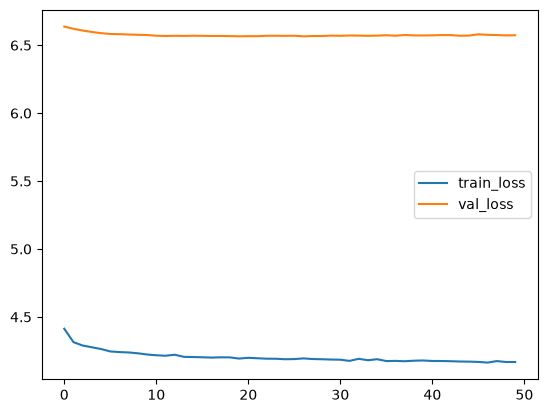

In [22]:
log_deepsurv.plot()

In [23]:
np.random.seed(42)
n_curves = min(5, len(surv_test.columns))
idx_selected = np.random.choice(range(n_curves), n_curves, replace=False)

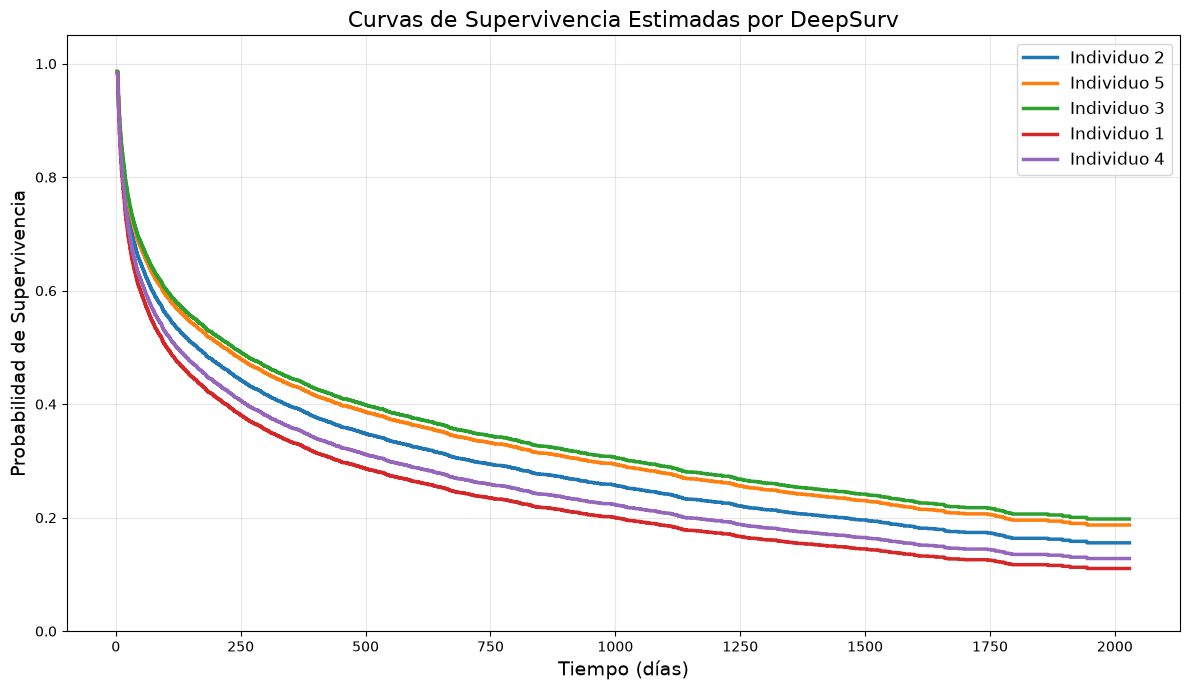

In [24]:
plt.figure(figsize=(12, 7))

times = surv_test.index.values

for i, idx in enumerate(idx_selected):
    survival_curve = surv_test.iloc[:, idx].values
    plt.step(times, survival_curve, where='post', 
             label=f'Individuo {idx+1}', linewidth=2.5)

plt.xlabel('Tiempo (días)', fontsize=14)
plt.ylabel('Probabilidad de Supervivencia', fontsize=14)
plt.title('Curvas de Supervivencia Estimadas por DeepSurv', fontsize=16)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()

In [25]:
print("\n" + "="*50)
print("TABLA COMPARATIVA DE RESULTADOS")
print("="*50)

comparison_df = pd.DataFrame({
    'Modelo': ['Cox Tradicional', 'DeepSurv (PyCox)'],
    'C-index': [c_index_cox, c_index_deepsurv],
    'Mejora': ['-', f'{(c_index_deepsurv - c_index_cox)*100:.2f}%']
})

print("\nTabla 1: Comparación de C-index en conjunto de prueba")
print(comparison_df.to_string(index=False))



TABLA COMPARATIVA DE RESULTADOS

Tabla 1: Comparación de C-index en conjunto de prueba
          Modelo  C-index Mejora
 Cox Tradicional 0.556051      -
DeepSurv (PyCox) 0.607641  5.16%
